# Classification Results — Trade Direction (Down / Flat / Up)

INFS3208 Individual Project — Distributed Market Analytics

Loads the RandomForestClassifier model already trained and saved by
`src/models/classification.py`. Predictors come from the first half of each
10-minute window (`seconds_in_bucket < 300`); the label is the direction of
the mid-price move in the second half — see `src/features/direction_labels.py`
for why a "next window" label (as used in the regression task) was not
valid here (time_id ordering is anonymised, not chronological).

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

sys.path.append(str(Path("../src/pipeline").resolve()))
sys.path.append(str(Path("../src/models").resolve()))

from spark_session import get_spark
from classification import FEATURE_COLS, DATA_PROCESSED, MODELS_DIR, load_split
from pyspark.ml import PipelineModel
from pyspark.ml.feature import IndexToString
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

spark = get_spark()
model = PipelineModel.load(str(MODELS_DIR / "classification_best"))
rf = model.stages[-1]
label_order = model.stages[0].labels  # StringIndexer's fitted label order
print("Loaded model:", type(rf).__name__, "| trees:", rf.getNumTrees, "| maxDepth:", rf.getOrDefault("maxDepth"))
print("Label order (index -> class):", list(enumerate(label_order)))

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/22 05:03:21 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Loaded model: RandomForestClassificationModel | trees: 100 | maxDepth: 8
Label order (index -> class): [(0, 'up'), (1, 'down'), (2, 'flat')]


## 1. Metrics across all three splits

With three roughly-balanced classes, random guessing scores ~33.3% accuracy —
this is the baseline every result below should be read against.

In [2]:
def evaluate_split(name):
    df = load_split(spark, name)
    pred = model.transform(df)
    acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy").evaluate(pred)
    f1 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1").evaluate(pred)
    return {"split": name, "accuracy": acc, "weighted_f1": f1}, pred

rows = []
preds = {}
for split_name in ["train", "val", "test"]:
    metrics, pred_df = evaluate_split(split_name)
    rows.append(metrics)
    preds[split_name] = pred_df

metrics_table = pd.DataFrame(rows).set_index("split")
metrics_table["vs_random_baseline"] = metrics_table["accuracy"] - (1 / 3)
metrics_table

26/09/22 05:03:27 WARN DAGScheduler: Broadcasting large task binary with size 3.3 MiB


26/09/22 05:03:31 WARN DAGScheduler: Broadcasting large task binary with size 3.3 MiB


26/09/22 05:03:34 WARN DAGScheduler: Broadcasting large task binary with size 3.3 MiB


26/09/22 05:03:35 WARN DAGScheduler: Broadcasting large task binary with size 3.3 MiB


26/09/22 05:03:36 WARN DAGScheduler: Broadcasting large task binary with size 3.3 MiB


26/09/22 05:03:37 WARN DAGScheduler: Broadcasting large task binary with size 3.3 MiB


,accuracy,weighted_f1,vs_random_baseline
split,,,
train,0.452370,0.438059,0.119037
val,0.426893,0.410208,0.093560
test,0.427019,0.409030,0.093686


## 2. Confusion matrix — test set

Rows are the true direction, columns are the predicted direction. A perfect
classifier would have all its mass on the diagonal; a classifier with no
signal at all would spread roughly evenly across each row.

26/09/22 05:03:37 WARN DAGScheduler: Broadcasting large task binary with size 3.3 MiB


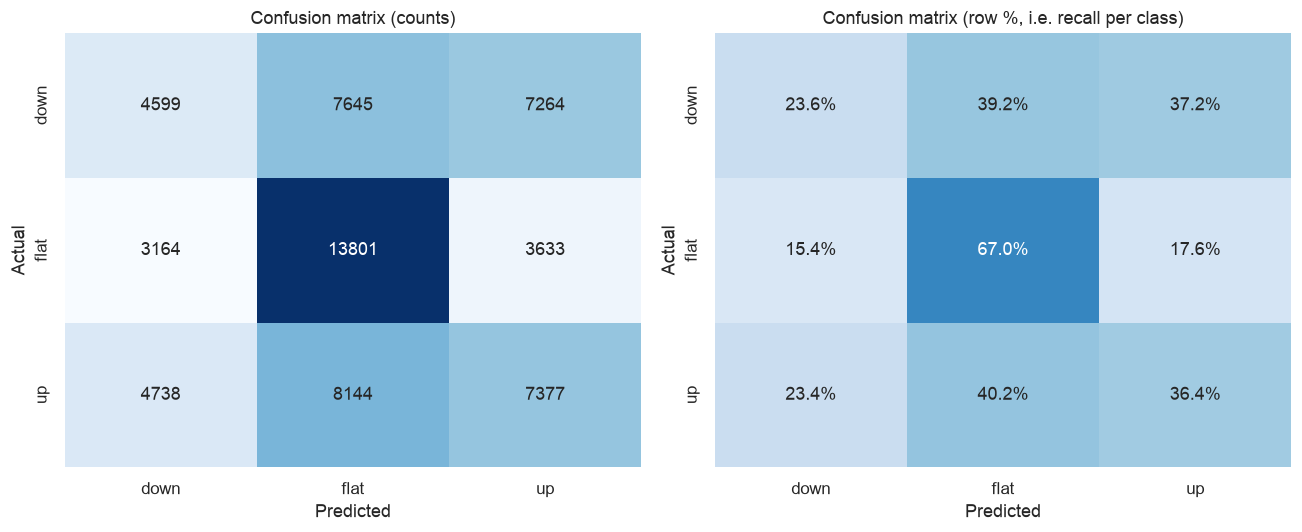

Per-class recall:
[0.23574944 0.67001651 0.36413446]


In [3]:
to_label = IndexToString(inputCol="prediction", outputCol="predicted_label", labels=label_order)
test_pred = to_label.transform(preds["test"])
test_pred_pd = test_pred.select("direction_label", "predicted_label").toPandas()

order = ["down", "flat", "up"]
cm = pd.crosstab(test_pred_pd["direction_label"], test_pred_pd["predicted_label"])
cm = cm.reindex(index=order, columns=order)
cm_pct = cm.div(cm.sum(axis=1), axis=0)  # row-normalised: % of each true class

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0], cbar=False)
axes[0].set_title("Confusion matrix (counts)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_pct, annot=True, fmt=".1%", cmap="Blues", ax=axes[1], cbar=False, vmin=0, vmax=1)
axes[1].set_title("Confusion matrix (row %, i.e. recall per class)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

print("Per-class recall:")
print((cm.values.diagonal() / cm.sum(axis=1).values))

## 3. Feature importance

Which early-window features the Random Forest relies on to guess direction.
Compare this to the regression task's feature importances (dominated by
`realized_vol_book` and `avg_spread_bps`) — a different ranking here would
indicate the model is picking up on genuinely different signal for
direction vs. volatility, not just reusing the same pattern.

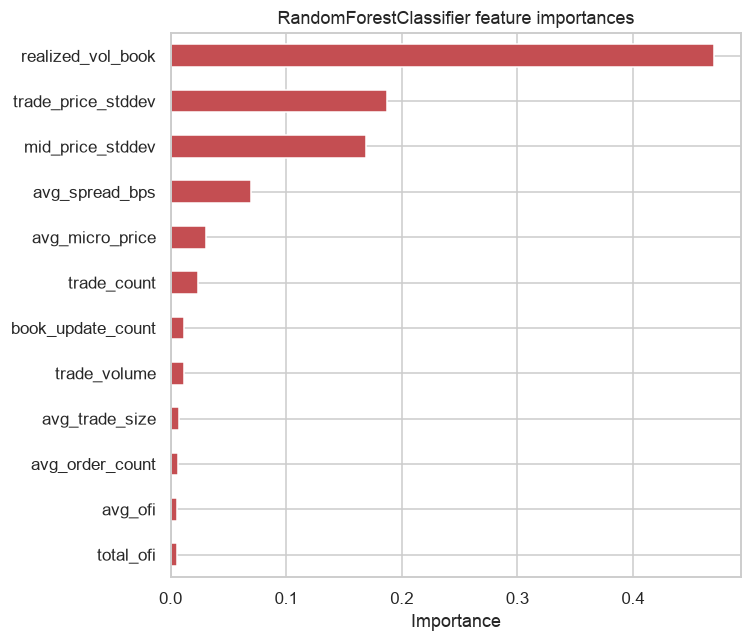

realized_vol_book     0.470304
trade_price_stddev    0.187264
mid_price_stddev      0.168693
avg_spread_bps        0.069583
avg_micro_price       0.030335
trade_count           0.024087
book_update_count     0.011991
trade_volume          0.011508
avg_trade_size        0.007757
avg_order_count       0.006857
avg_ofi               0.005945
total_ofi             0.005675
dtype: float64

In [4]:
importances = pd.Series(
    rf.featureImportances.toArray(), index=FEATURE_COLS
).sort_values(ascending=True)

plt.figure(figsize=(7, 6))
importances.plot.barh(color="#C44E52")
plt.title("RandomForestClassifier feature importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances.sort_values(ascending=False)

## 4. Class balance check

Confirms the tertile-threshold labeling (fit on train, applied unchanged to
val/test) produced balanced classes across all three splits, as intended.

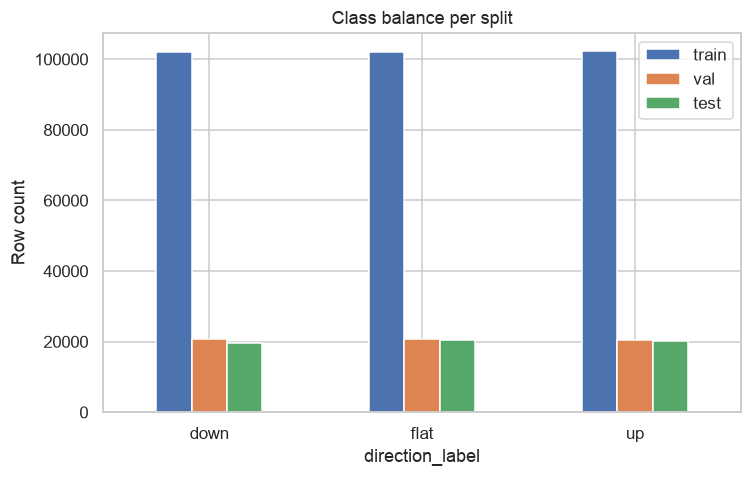

,train,val,test
direction_label,,,
down,102156,20732,19508
flat,102077,20862,20598
up,102288,20452,20259


In [5]:
balance = pd.concat({
    name: preds[name].groupBy("direction_label").count().toPandas().set_index("direction_label")["count"]
    for name in ["train", "val", "test"]
}, axis=1)
balance = balance.reindex(["down", "flat", "up"])

balance.plot(kind="bar", figsize=(7, 4.5), color=["#4C72B0", "#DD8452", "#55A868"])
plt.title("Class balance per split")
plt.ylabel("Row count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

balance

## Takeaways

- **Test accuracy 42.7%, weighted F1 0.41** — meaningfully above the 33.3%
  random baseline for 3 balanced classes, but far from strong. This is a
  genuine, expected result: short-horizon price *direction* is famously
  close to a random walk (the intuition behind weak-form market
  efficiency), unlike *volatility*, which the regression task showed is
  highly predictable (R²=0.82). The contrast between the two tasks is
  itself a finding worth stating explicitly.
- **The model is biased toward predicting "flat"** (see the confusion
  matrix) rather than confidently calling direction — consistent with weak,
  noisy signal rather than a strong directional edge.
- Feature importances here should be compared against the regression task's
  ranking to see whether direction prediction leans on different signals
  (e.g. OFI, which barely mattered for volatility) than volatility
  prediction does.

In [6]:
spark.stop()